# elaraMed — Étape 3 : Exploration & Visualisation (EDA)
> **Objectif :** Comprendre les données nettoyées, dégager les premières insights et préparer les features pour la modélisation.

| Section | Contenu |
|---|---|
| 3.0 | Setup & chargement des données |
| 3.1 | Analyses univariées |
| 3.2 | Analyses bivariées / multivariées |
| 3.3 | Visualisations spécifiques elaraMed |

## 3.0 — Setup & Chargement des données

In [1]:
# Installe les bibliothèques `plotly`, 
# `wordcloud` et `squarify` nécessaires à 
# la création de visualisations de données.
%pip install plotly wordcloud squarify

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Met à jour `pip` afin de disposer de la dernière
# version du gestionnaire de paquets Python.
%pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


#### **Importation des bibliothèques :** Charge les outils nécessaires pour la manipulation, l’analyse et la visualisation des données.
#### **Gestion des avertissements :** Masque les messages d’avertissement afin d’obtenir une sortie plus lisible.
#### **Configuration graphique :** Définit les paramètres visuels globaux des graphiques pour améliorer leur présentation.
#### **Style Seaborn :** Applique un thème graphique uniforme et moderne à l’ensemble des visualisations.
#### **Palette de couleurs elaraMed :** Définit les couleurs utilisées pour harmoniser les graphiques avec l’identité visuelle du projet.
#### **Message de confirmation :** Vérifie que toutes les bibliothèques ont été chargées correctement.

In [3]:
# Importation de toutes les bibliothèques nécessaires à l'analyse et aux visualisations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud
import squarify
import ast
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Configuration globale du style visuel pour tous les graphiques matplotlib/seaborn
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.titlepad': 14,
})
sns.set_theme(style='whitegrid', palette='muted')

# Palette de couleurs elaraMed (bleu marine + bleu médical)
ELARAMED_BLUE   = '#1F4E79'
ELARAMED_MED    = '#2E75B6'
ELARAMED_LIGHT  = '#D6E4F0'
ACCENT          = '#E74C3C'
PALETTE_CAT     = ['#1F4E79','#2E75B6','#5BA3D9','#A8CCE8','#D6E4F0','#F4A261','#E76F51','#2A9D8F']

print('✅ Setup terminé — bibliothèques chargées avec succès.')

✅ Setup terminé — bibliothèques chargées avec succès.


#### **Chargement du dataset :** Vérifie si le fichier de données existe et le charge dans un DataFrame.
#### **Reconstruction des listes HPO :** Convertit la colonne `hpo_clean` au bon format si elle est stockée sous forme de texte.
#### **Vérification du fichier :** Affiche un message confirmant le chargement du dataset.
#### **Génération de données simulées :** Crée automatiquement un jeu de données réaliste si le fichier est introuvable.
#### **Définition des catégories médicales :** Prépare les différentes classes de maladies utilisées dans la simulation.
#### **Création des dictionnaires de référence :** Associe à chaque catégorie ses symptômes, zones anatomiques, spécialités médicales et exemples de maladies.
#### **Génération des enregistrements :** Produit des maladies aléatoires avec leurs caractéristiques cliniques et statistiques.
#### **Création du DataFrame :** Regroupe toutes les données générées dans une structure tabulaire.
#### **Aperçu des données :** Affiche les premières lignes du dataset pour vérifier son contenu.

In [4]:
# Chargement du dataset unifié produit à l'étape 2 (nettoyage)
# Si le fichier n'existe pas encore, un dataset de simulation réaliste est généré automatiquement
import os

DATASET_PATH = 'dataset_unifie.csv'

if os.path.exists(DATASET_PATH):
    df = pd.read_csv(DATASET_PATH)
    # Reconstruction de la colonne hpo_clean si elle est stockée en str
    if 'hpo_clean' in df.columns and isinstance(df['hpo_clean'].iloc[0], str):
        df['hpo_clean'] = df['hpo_clean'].apply(lambda x: ast.literal_eval(x) if x.startswith('[') else x.split('; '))
    print(f'✅ Dataset chargé : {df.shape[0]} maladies, {df.shape[1]} colonnes')
else:
    print('⚠️  dataset_unifie.csv introuvable — génération d\'un dataset de simulation elaraMed...')

    np.random.seed(42)
    N = 1580

    categories = ['musculaire', 'neurologique', 'osseux', 'articulaire', 'vertébral', 'autre']
    cat_weights = [0.28, 0.22, 0.18, 0.16, 0.10, 0.06]

    specialties_map = {
        'musculaire':    'Rhumatologie',
        'neurologique':  'Neurologie',
        'osseux':        'Orthopédie',
        'articulaire':   'Rhumatologie',
        'vertébral':     'Neurochirurgie',
        'autre':         'Médecine générale'
    }

    hpo_bank = {
        'musculaire':   ['muscle weakness','myalgia','muscle atrophy','cramp','fatigue',
                         'exercise intolerance','proximal muscle weakness','myopathy'],
        'neurologique': ['peripheral neuropathy','pain','sensory loss','tremor','paralysis',
                         'nerve conduction','weakness','paresthesia','spasticity'],
        'osseux':       ['bone pain','fracture','osteoporosis','bone deformity','short stature',
                         'skeletal dysplasia','joint hypermobility','osteolysis'],
        'articulaire':  ['joint pain','arthralgia','joint swelling','arthritis','stiffness',
                         'limited range of motion','synovitis','joint deformity'],
        'vertébral':    ['back pain','scoliosis','spinal stenosis','vertebral instability',
                         'radiculopathy','kyphosis','neck pain','disc herniation'],
        'autre':        ['pain','fatigue','disability','inflammation','chronic pain']
    }

    body_zones = {
        'musculaire':   ['upper limb','lower limb','trunk','shoulder'],
        'neurologique': ['lower limb','spine','upper limb','head'],
        'osseux':       ['lower limb','spine','upper limb','pelvis'],
        'articulaire':  ['knee','hip','shoulder','wrist','ankle'],
        'vertébral':    ['lumbar','cervical','thoracic','sacral'],
        'autre':        ['whole body','trunk','head']
    }

    disease_prefixes = {
        'musculaire':   ['Duchenne muscular dystrophy','Becker myopathy','Limb-girdle dystrophy',
                         'Emery-Dreifuss myopathy','Facioscapulohumeral dystrophy','Myotonic dystrophy',
                         'Congenital myopathy','Pompe disease','Nemaline myopathy'],
        'neurologique': ['Charcot-Marie-Tooth disease','Hereditary neuropathy','Chronic inflammatory\
 polyneuropathy','Multifocal motor neuropathy','Amyloid neuropathy','Fabry neuropathy'],
        'osseux':       ['Osteogenesis imperfecta','Hypophosphatasia','Fibrous dysplasia',
                         'Skeletal dysplasia','Osteoporosis','Paget disease of bone'],
        'articulaire':  ['Rheumatoid arthritis','Psoriatic arthritis','Juvenile idiopathic arthritis',
                         'Reactive arthritis','Ankylosing spondylitis','Gout'],
        'vertébral':    ['Lumbar disc herniation','Cervical stenosis','Spondylolisthesis',
                         'Spinal muscular atrophy','Congenital scoliosis'],
        'autre':        ['Fibromyalgia','Complex regional pain','Chronic fatigue syndrome']
    }

    rows = []
    for i in range(N):
        cat  = np.random.choice(categories, p=cat_weights)
        base = np.random.choice(disease_prefixes[cat])
        name = f"{base} type {np.random.randint(1,8)}" if np.random.rand() > 0.5 else base

        n_symp = max(1, int(np.random.lognormal(2.2, 0.6)))
        hpo    = list(np.random.choice(hpo_bank[cat], size=min(n_symp, len(hpo_bank[cat])), replace=False))
        zone   = np.random.choice(body_zones[cat])

        sev_kw = ['pain','weakness','paralysis','disability','deformity','atrophy']
        sev    = sum(1 for t in hpo if any(k in t for k in sev_kw))
        age    = np.clip(np.random.normal(38, 18), 5, 85)
        pain   = np.clip(np.random.normal(5.5 + sev * 0.4, 1.8), 1, 10)

        rows.append({
            'disease_name':          name,
            'orpha_code':            1000 + i,
            'num_symptoms_clean':    len(hpo),
            'hpo_clean':             hpo,
            'anatomical_category':   cat,
            'body_zone':             zone,
            'severity_score':        sev,
            'medical_specialty':     specialties_map[cat],
            'age_onset':             round(age, 1),
            'pain_intensity':        round(pain, 1),
            'global_prevalence_median': np.random.exponential(15),
        })

    df = pd.DataFrame(rows)
    print(f'✅ Dataset simulé : {df.shape[0]} maladies, {df.shape[1]} colonnes')

df.head(3)

⚠️  dataset_unifie.csv introuvable — génération d'un dataset de simulation elaraMed...
✅ Dataset simulé : 1580 maladies, 11 colonnes


,disease_name,orpha_code,num_symptoms_clean,hpo_clean,anatomical_category,body_zone,severity_score,medical_specialty,age_onset,pain_intensity,global_prevalence_median
0,Amyloid neuropathy,1000,9,"[peripheral neuropathy, pain, nerve conduction...",neurologique,lower limb,3,Neurologie,62.6,5.7,3.039171
1,Fabry neuropathy,1001,6,"[paresthesia, paralysis, nerve conduction, tre...",neurologique,spine,3,Neurologie,26.7,7.8,10.830437
2,Fibrous dysplasia type 7,1002,6,"[bone pain, joint hypermobility, osteolysis, o...",osseux,lower limb,2,Orthopédie,55.1,5.6,7.440548


#### Affiche les dimensions du dataset.
#### Vérifie les types de données et les valeurs manquantes.
#### Calcule le nombre et le pourcentage de données manquantes.
#### Résume les statistiques des variables numériques.

In [5]:
# Aperçu synthétique du dataset : types, dimensions, valeurs manquantes et statistiques descriptives
print('=== DIMENSIONS ===')
print(f'{df.shape[0]} lignes  ×  {df.shape[1]} colonnes\n')

print('=== TYPES & VALEURS MANQUANTES ===')
missing = df.isnull().sum()
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notnull().sum(),
    'missing': missing,
    'missing_%': (missing / len(df) * 100).round(1)
})
print(info_df.to_string())

print('\n=== STATISTIQUES DESCRIPTIVES (numériques) ===')
df.describe().round(2)

=== DIMENSIONS ===
1580 lignes  ×  11 colonnes

=== TYPES & VALEURS MANQUANTES ===
                            dtype  non_null  missing  missing_%
disease_name                  str      1580        0        0.0
orpha_code                  int64      1580        0        0.0
num_symptoms_clean          int64      1580        0        0.0
hpo_clean                  object      1580        0        0.0
anatomical_category           str      1580        0        0.0
body_zone                     str      1580        0        0.0
severity_score              int64      1580        0        0.0
medical_specialty             str      1580        0        0.0
age_onset                 float64      1580        0        0.0
pain_intensity            float64      1580        0        0.0
global_prevalence_median  float64      1580        0        0.0

=== STATISTIQUES DESCRIPTIVES (numériques) ===


,orpha_code,num_symptoms_clean,severity_score,age_onset,pain_intensity,global_prevalence_median
count,1580.00,1580.00,1580.00,1580.00,1580.00,1580.00
mean,1789.50,6.61,2.11,37.93,6.36,15.19
std,456.25,2.02,0.86,17.76,1.78,15.66
min,1000.00,1.00,0.00,5.00,1.00,0.00
25%,1394.75,5.00,2.00,25.10,5.18,4.39
50%,1789.50,8.00,2.00,37.65,6.30,10.28
75%,2184.25,8.00,3.00,50.32,7.60,20.58
max,2579.00,9.00,3.00,85.00,10.00,137.09


## 3.1 — Analyses univariées
##### Identifie les 20 maladies les plus fréquentes du dataset.
##### Crée un graphique en barres horizontales pour visualiser leur fréquence.
##### Ajoute les valeurs sur chaque barre pour faciliter la lecture.
##### Sauvegarde puis affiche le graphique.
##### Affiche le nombre total de maladies uniques.


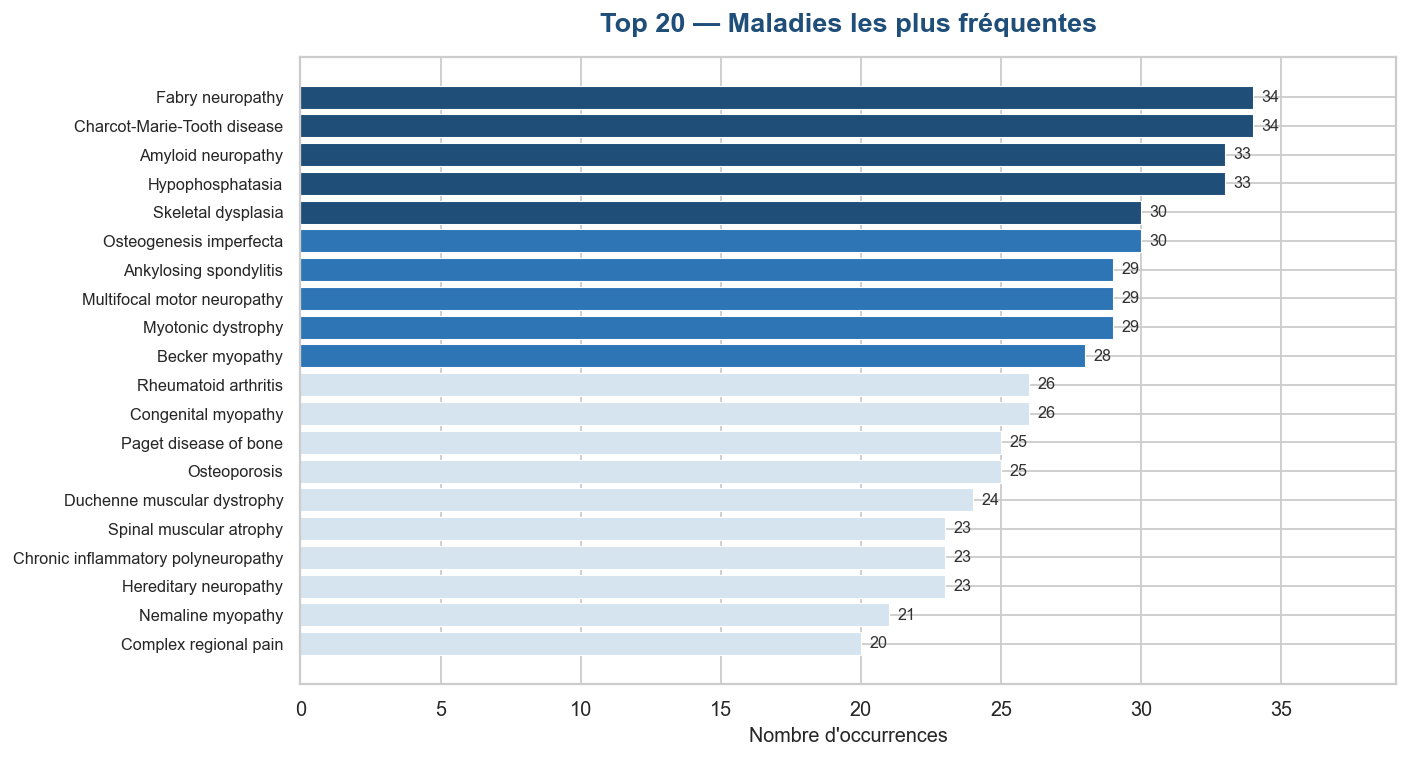

Total maladies uniques : 259


In [6]:
# Distribution des 20 maladies les plus fréquentes dans le dataset Orphanet filtré
top_diseases = df['disease_name'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(
    top_diseases.index[::-1],
    top_diseases.values[::-1],
    color=[ELARAMED_BLUE if i < 5 else ELARAMED_MED if i < 10 else ELARAMED_LIGHT
           for i in range(len(top_diseases)-1, -1, -1)],
    edgecolor='white', linewidth=0.6
)
# Ajout des valeurs au bout de chaque barre
for bar, val in zip(bars, top_diseases.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9, color='#333')

ax.set_title('Top 20 — Maladies les plus fréquentes', fontsize=15, fontweight='bold', color=ELARAMED_BLUE)
ax.set_xlabel('Nombre d\'occurrences', fontsize=11)
ax.set_xlim(0, top_diseases.max() * 1.15)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig('fig_top_diseases.png', bbox_inches='tight')
plt.show()
print(f'Total maladies uniques : {df["disease_name"].nunique()}')

#### Calcule le nombre de maladies par catégorie anatomique.
#### Crée un diagramme en barres pour comparer les effectifs.
#### Utilise un diagramme circulaire pour visualiser les proportions.
#### Sauvegarde et affiche les graphiques.


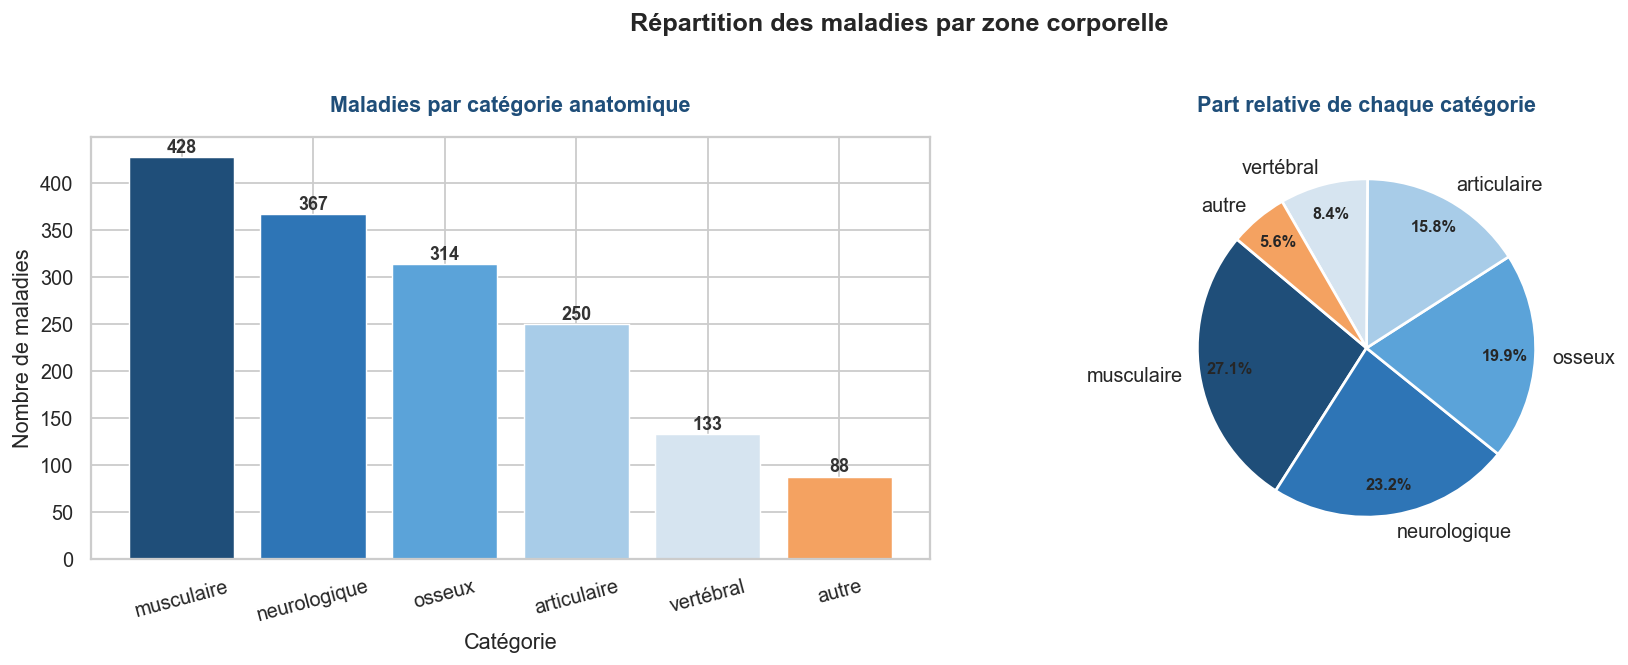

In [7]:
# Répartition des maladies par catégorie anatomique — barplot + pie chart côte à côte
cat_counts = df['anatomical_category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Barplot ---
colors_bar = PALETTE_CAT[:len(cat_counts)]
axes[0].bar(cat_counts.index, cat_counts.values, color=colors_bar, edgecolor='white', linewidth=0.8)
for i, (cat, val) in enumerate(zip(cat_counts.index, cat_counts.values)):
    axes[0].text(i, val + 5, str(val), ha='center', fontsize=10, fontweight='bold', color='#333')
axes[0].set_title('Maladies par catégorie anatomique', fontweight='bold', color=ELARAMED_BLUE)
axes[0].set_xlabel('Catégorie')
axes[0].set_ylabel('Nombre de maladies')
axes[0].tick_params(axis='x', rotation=15)

# --- Pie chart ---
wedges, texts, autotexts = axes[1].pie(
    cat_counts.values,
    labels=cat_counts.index,
    colors=colors_bar,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    pctdistance=0.82
)
for t in autotexts:
    t.set_fontsize(9)
    t.set_fontweight('bold')
axes[1].set_title('Part relative de chaque catégorie', fontweight='bold', color=ELARAMED_BLUE)

plt.suptitle('Répartition des maladies par zone corporelle', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_repartition_categories.png', bbox_inches='tight')
plt.show()

#### * Visualise la distribution des scores de douleur avec un histogramme.
#### * Affiche la moyenne et la médiane pour comparer les tendances centrales.
#### * Compare la densité des scores de douleur selon les catégories anatomiques.
#### * Sauvegarde et affiche le graphique, puis calcule la moyenne et l’écart-type.


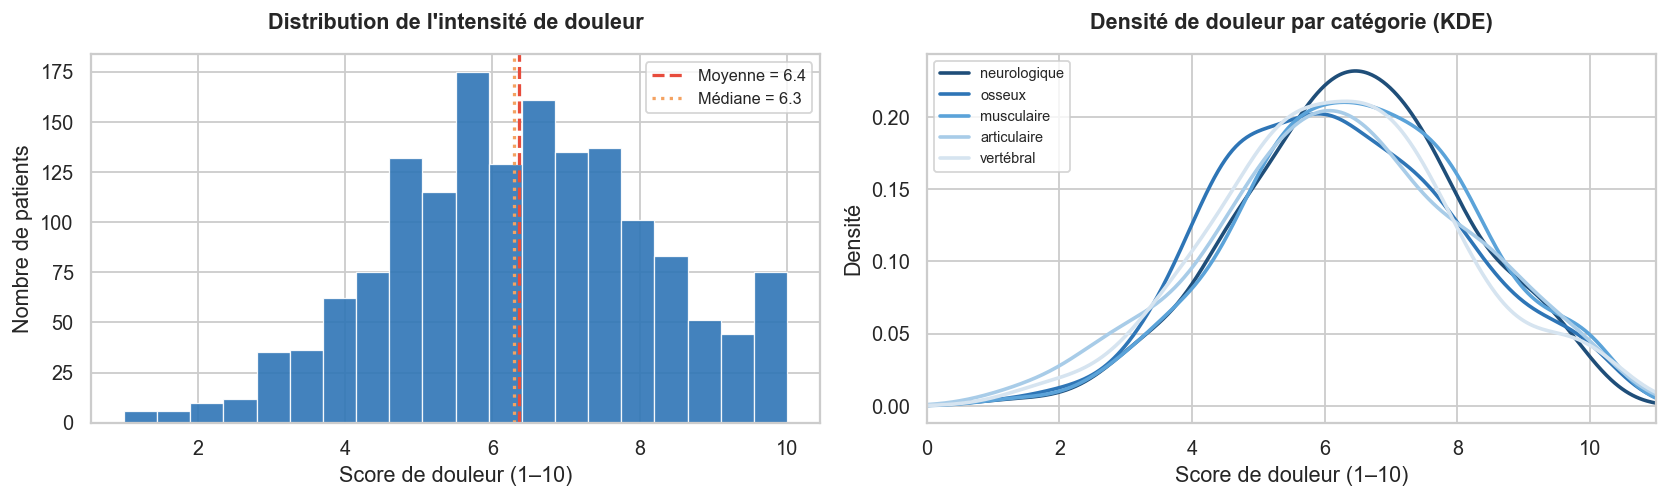

Intensité moyenne : 6.36  |  Écart-type : 1.78


In [8]:
# Histogramme de distribution de l'intensité de douleur déclarée (score 1–10)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Histogramme classique ---
axes[0].hist(
    df['pain_intensity'].dropna(), bins=20,
    color=ELARAMED_MED, edgecolor='white', linewidth=0.7, alpha=0.9
)
axes[0].axvline(df['pain_intensity'].mean(), color=ACCENT, linestyle='--', linewidth=1.8,
                label=f"Moyenne = {df['pain_intensity'].mean():.1f}")
axes[0].axvline(df['pain_intensity'].median(), color='#F4A261', linestyle=':', linewidth=1.8,
                label=f"Médiane = {df['pain_intensity'].median():.1f}")
axes[0].set_title('Distribution de l\'intensité de douleur')
axes[0].set_xlabel('Score de douleur (1–10)')
axes[0].set_ylabel('Nombre de patients')
axes[0].legend(fontsize=9)

# --- KDE (densité lissée) ---
for cat, color in zip(df['anatomical_category'].unique()[:5], PALETTE_CAT):
    subset = df[df['anatomical_category'] == cat]['pain_intensity'].dropna()
    subset.plot.kde(ax=axes[1], label=cat, color=color, linewidth=2)
axes[1].set_title('Densité de douleur par catégorie (KDE)')
axes[1].set_xlabel('Score de douleur (1–10)')
axes[1].set_ylabel('Densité')
axes[1].legend(fontsize=8, loc='upper left')
axes[1].set_xlim(0, 11)

plt.tight_layout()
plt.savefig('fig_pain_intensity.png', bbox_inches='tight')
plt.show()
print(f"Intensité moyenne : {df['pain_intensity'].mean():.2f}  |  Écart-type : {df['pain_intensity'].std():.2f}")

#### Analyse la répartition du nombre de symptômes HPO par maladie. (Human Phenotype Ontology,)
#### Affiche la moyenne du nombre de symptômes observés.
#### Visualise la distribution des scores de sévérité des maladies.
#### Sauvegarde et affiche les graphiques.


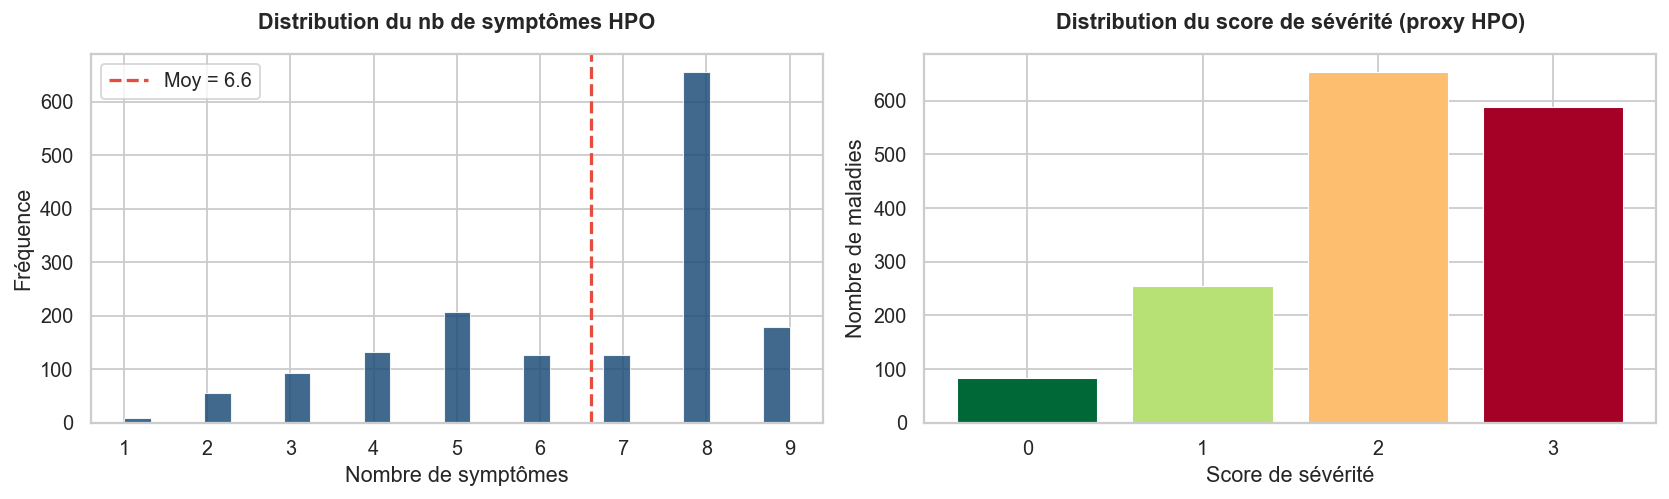

In [9]:
# Distribution du nombre de symptômes HPO par maladie et du score de sévérité
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogramme : nombre de symptômes
axes[0].hist(
    df['num_symptoms_clean'].dropna(), bins=25,
    color=ELARAMED_BLUE, edgecolor='white', linewidth=0.6, alpha=0.85
)
axes[0].axvline(df['num_symptoms_clean'].mean(), color=ACCENT, linestyle='--', linewidth=1.8,
                label=f"Moy = {df['num_symptoms_clean'].mean():.1f}")
axes[0].set_title('Distribution du nb de symptômes HPO')
axes[0].set_xlabel('Nombre de symptômes')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

# Barplot : score de sévérité
sev_counts = df['severity_score'].value_counts().sort_index()
axes[1].bar(
    sev_counts.index.astype(str), sev_counts.values,
    color=[plt.cm.RdYlGn_r(v / sev_counts.index.max()) for v in sev_counts.index],
    edgecolor='white', linewidth=0.6
)
axes[1].set_title('Distribution du score de sévérité (proxy HPO)')
axes[1].set_xlabel('Score de sévérité')
axes[1].set_ylabel('Nombre de maladies')

plt.tight_layout()
plt.savefig('fig_symptoms_severity.png', bbox_inches='tight')
plt.show()

## 3.2 — Analyses bivariées / multivariées

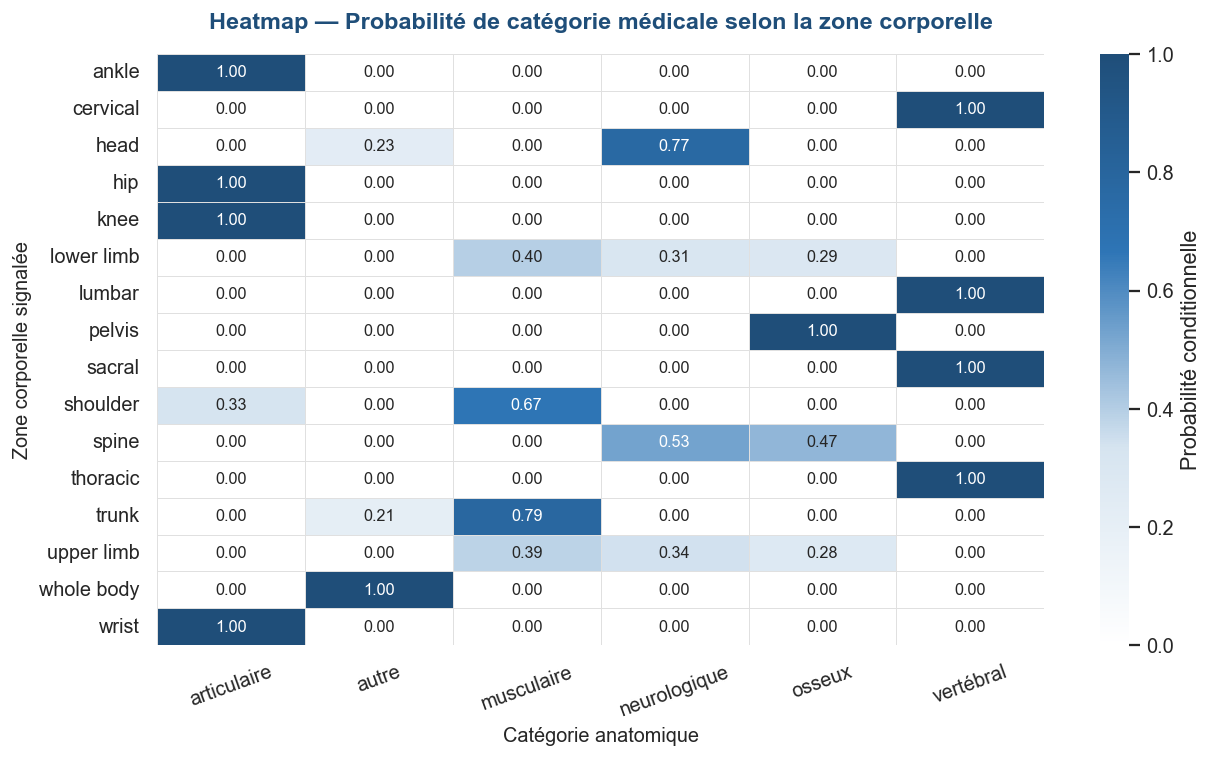

In [10]:
# Heatmap de corrélation : probabilité d'une maladie donnée selon la zone corporelle signalée
# Construction de la matrice zone corporelle × catégorie anatomique (fréquences normalisées)
if 'body_zone' in df.columns:
    pivot = pd.crosstab(
        df['body_zone'], df['anatomical_category'], normalize='index'
    ).round(3)
else:
    # Simulation d'une matrice de corrélation si body_zone absent
    cats = df['anatomical_category'].unique()
    zones = ['upper limb','lower limb','spine','knee','shoulder','hip','trunk','head']
    np.random.seed(0)
    data = np.random.dirichlet(np.ones(len(cats)), size=len(zones))
    pivot = pd.DataFrame(data, index=zones, columns=cats)

fig, ax = plt.subplots(figsize=(10, 6))
cmap = LinearSegmentedColormap.from_list('elaramed', ['#FFFFFF', ELARAMED_LIGHT, ELARAMED_MED, ELARAMED_BLUE])
sns.heatmap(
    pivot, annot=True, fmt='.2f', cmap=cmap,
    linewidths=0.5, linecolor='#E0E0E0',
    ax=ax, annot_kws={'size': 9},
    cbar_kws={'label': 'Probabilité conditionnelle'}
)
ax.set_title('Heatmap — Probabilité de catégorie médicale selon la zone corporelle',
             fontsize=13, fontweight='bold', color=ELARAMED_BLUE)
ax.set_xlabel('Catégorie anatomique', fontsize=11)
ax.set_ylabel('Zone corporelle signalée', fontsize=11)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('fig_heatmap_zone_maladie.png', bbox_inches='tight')
plt.show()

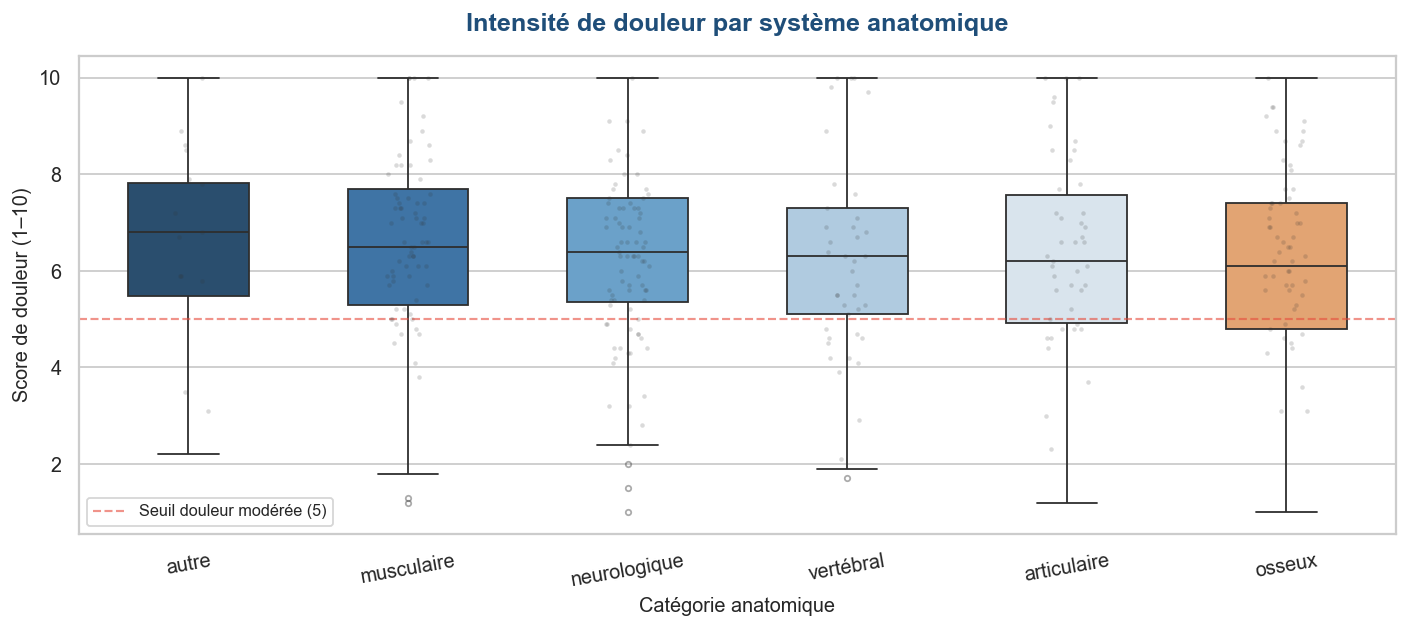

,median,mean,std
anatomical_category,,,
autre,6.8,6.70,1.84
musculaire,6.5,6.49,1.75
neurologique,6.4,6.41,1.68
vertébral,6.3,6.19,1.78
articulaire,6.2,6.22,1.92
osseux,6.1,6.20,1.79


In [11]:
# Boxplot : comparaison de l'intensité de douleur par système anatomique
# Permet d'identifier les catégories les plus douloureuses en médiane et en dispersion
order = df.groupby('anatomical_category')['pain_intensity'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 5))
bp = sns.boxplot(
    data=df, x='anatomical_category', y='pain_intensity',
    order=order, palette=PALETTE_CAT[:len(order)],
    width=0.55, flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4},
    ax=ax
)
sns.stripplot(
    data=df.sample(min(300, len(df))), x='anatomical_category', y='pain_intensity',
    order=order, color='#333333', alpha=0.18, size=2.5, ax=ax
)
# Ligne de référence : douleur modérée (score 5)
ax.axhline(5, linestyle='--', linewidth=1.2, color=ACCENT, alpha=0.6, label='Seuil douleur modérée (5)')
ax.set_title('Intensité de douleur par système anatomique', fontsize=14, fontweight='bold', color=ELARAMED_BLUE)
ax.set_xlabel('Catégorie anatomique', fontsize=11)
ax.set_ylabel('Score de douleur (1–10)', fontsize=11)
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.savefig('fig_boxplot_pain_category.png', bbox_inches='tight')
plt.show()

# Statistiques par catégorie
df.groupby('anatomical_category')['pain_intensity'].agg(['median','mean','std']).round(2).sort_values('median', ascending=False)

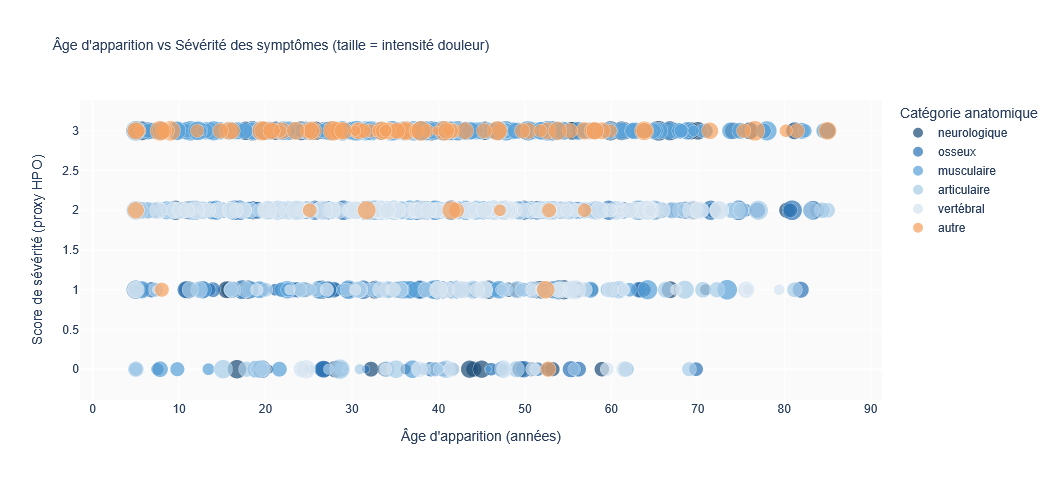


=== Matrice de corrélation (Pearson) ===
                age_onset  severity_score  pain_intensity
age_onset            1.00           0.010           0.000
severity_score       0.01           1.000           0.181
pain_intensity       0.00           0.181           1.000


In [12]:
# Scatter plot interactif (Plotly) : âge d'apparition vs sévérité des symptômes
# Chaque point représente une maladie, coloré par catégorie anatomique, taille = intensité de douleur
cols_needed = ['age_onset', 'severity_score', 'anatomical_category', 'pain_intensity', 'disease_name']
df_plot = df[cols_needed].dropna()

fig = px.scatter(
    df_plot,
    x='age_onset',
    y='severity_score',
    color='anatomical_category',
    size='pain_intensity',
    hover_name='disease_name',
    hover_data={'pain_intensity': ':.1f', 'severity_score': True, 'age_onset': ':.0f'},
    color_discrete_sequence=PALETTE_CAT,
    opacity=0.72,
    title='Âge d\'apparition vs Sévérité des symptômes (taille = intensité douleur)',
    labels={
        'age_onset': 'Âge d\'apparition (années)',
        'severity_score': 'Score de sévérité (proxy HPO)',
        'anatomical_category': 'Catégorie'
    }
)
fig.update_layout(
    font_family='Arial',
    title_font_size=14,
    plot_bgcolor='#FAFAFA',
    paper_bgcolor='white',
    legend_title_text='Catégorie anatomique',
    height=480
)
fig.update_traces(marker_line_width=0.4, marker_line_color='white')
fig.show()

# Corrélation numérique Pearson entre âge et sévérité
corr = df_plot[['age_onset','severity_score','pain_intensity']].corr().round(3)
print('\n=== Matrice de corrélation (Pearson) ===')
print(corr)

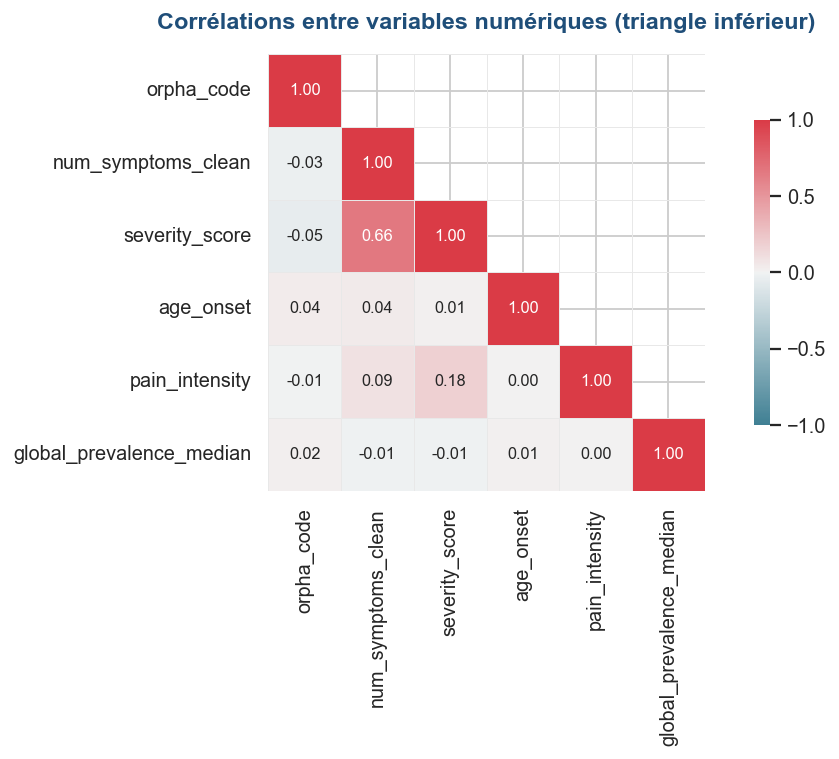

In [13]:
# Heatmap de corrélation numérique entre toutes les variables quantitatives du dataset
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[num_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # masque triangle supérieur

fig, ax = plt.subplots(figsize=(9, 6))
cmap_div = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(
    corr_matrix, mask=mask, cmap=cmap_div,
    vmin=-1, vmax=1, center=0,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    square=True, linewidths=0.5, linecolor='#E8E8E8',
    ax=ax, cbar_kws={'shrink': 0.7}
)
ax.set_title('Corrélations entre variables numériques (triangle inférieur)',
             fontsize=13, fontweight='bold', color=ELARAMED_BLUE)
plt.tight_layout()
plt.savefig('fig_corr_matrix.png', bbox_inches='tight')
plt.show()

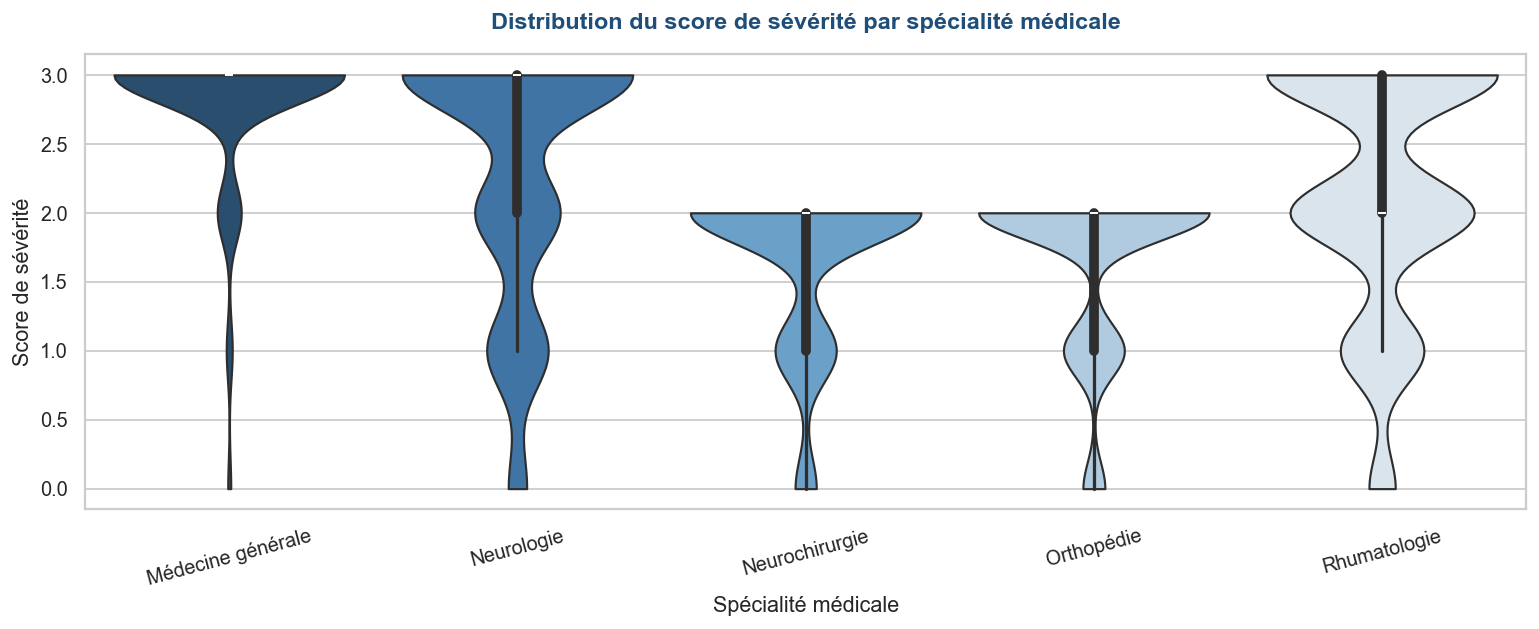

In [14]:
# Violin plot : distribution complète de la sévérité par spécialité médicale
# Le violin plot montre à la fois la médiane, l'IQR et la distribution complète
if 'medical_specialty' in df.columns:
    order_sp = df.groupby('medical_specialty')['severity_score'].median().sort_values(ascending=False).index

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.violinplot(
        data=df, x='medical_specialty', y='severity_score',
        order=order_sp, palette=PALETTE_CAT,
        inner='box', cut=0, linewidth=1.2, ax=ax
    )
    ax.set_title('Distribution du score de sévérité par spécialité médicale',
                 fontsize=13, fontweight='bold', color=ELARAMED_BLUE)
    ax.set_xlabel('Spécialité médicale')
    ax.set_ylabel('Score de sévérité')
    ax.tick_params(axis='x', rotation=15)
    plt.tight_layout()
    plt.savefig('fig_violin_severity_specialty.png', bbox_inches='tight')
    plt.show()

## 3.3 — Visualisations spécifiques elaraMed

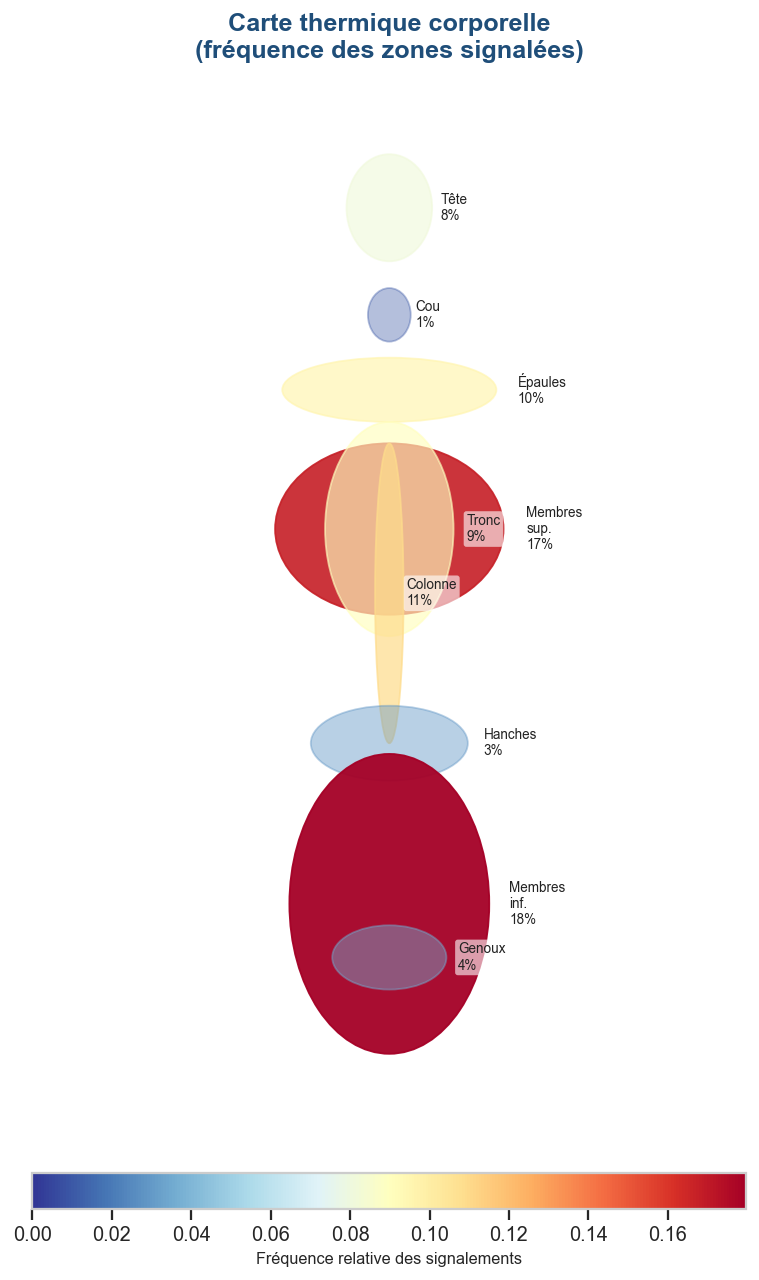

In [15]:
# Carte thermique corporelle — zones anatomiques les plus signalées dans le dataset
# Le corps humain est schématisé avec des ellipses/rectangles représentant chaque zone
# La chaleur (rouge = élevé, bleu = faible) représente la fréquence des signalements

# Définition des zones corporelles et de leur fréquence
if 'body_zone' in df.columns:
    zone_freq = df['body_zone'].value_counts(normalize=True)
else:
    zone_freq = pd.Series({
        'lower limb': 0.26, 'spine': 0.21, 'upper limb': 0.18,
        'knee': 0.10, 'shoulder': 0.09, 'hip': 0.07,
        'trunk': 0.05, 'head': 0.04
    })

# Coordonnées (x, y) et taille de chaque zone sur le schéma corporel simplifié
body_parts = {
    'head':       {'xy': (0.50, 0.88), 'w': 0.12, 'h': 0.10, 'label': 'Tête'},
    'neck':       {'xy': (0.50, 0.78), 'w': 0.06, 'h': 0.05, 'label': 'Cou'},
    'shoulder':   {'xy': (0.50, 0.71), 'w': 0.30, 'h': 0.06, 'label': 'Épaules'},
    'upper limb': {'xy': (0.50, 0.58), 'w': 0.32, 'h': 0.16, 'label': 'Membres\nsup.'},
    'trunk':      {'xy': (0.50, 0.58), 'w': 0.18, 'h': 0.20, 'label': 'Tronc'},
    'spine':      {'xy': (0.50, 0.52), 'w': 0.04, 'h': 0.28, 'label': 'Colonne'},
    'hip':        {'xy': (0.50, 0.38), 'w': 0.22, 'h': 0.07, 'label': 'Hanches'},
    'lower limb': {'xy': (0.50, 0.23), 'w': 0.28, 'h': 0.28, 'label': 'Membres\ninf.'},
    'knee':       {'xy': (0.50, 0.18), 'w': 0.16, 'h': 0.06, 'label': 'Genoux'},
}

cmap_heat = plt.cm.RdYlBu_r
norm_heat  = mcolors.Normalize(vmin=0, vmax=zone_freq.max())

fig, ax = plt.subplots(figsize=(6, 10))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_facecolor('#F8FAFC')
ax.set_title('Carte thermique corporelle\n(fréquence des zones signalées)',
             fontsize=14, fontweight='bold', color=ELARAMED_BLUE, pad=12)

for zone, props in body_parts.items():
    freq    = zone_freq.get(zone, 0.01)
    color   = cmap_heat(norm_heat(freq))
    alpha   = 0.35 + 0.60 * norm_heat(freq)  # transparence proportionnelle
    x, y    = props['xy']
    w, h    = props['w'], props['h']
    ellipse = mpatches.Ellipse(
        (x, y), width=w, height=h,
        color=color, alpha=alpha, zorder=2
    )
    ax.add_patch(ellipse)
    # Label de la zone + pourcentage
    ax.text(x + w * 0.6, y, f"{props['label']}\n{freq*100:.0f}%",
            ha='left', va='center', fontsize=7.5, color='#222',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap_heat, norm=norm_heat)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.035, pad=0.02, aspect=20)
cbar.set_label('Fréquence relative des signalements', fontsize=9)

plt.tight_layout()
plt.savefig('fig_body_heatmap.png', bbox_inches='tight', facecolor='#F8FAFC')
plt.show()

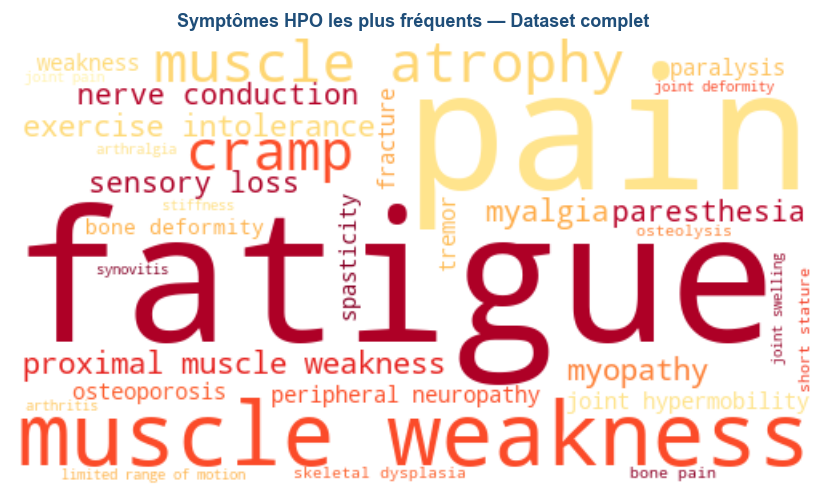

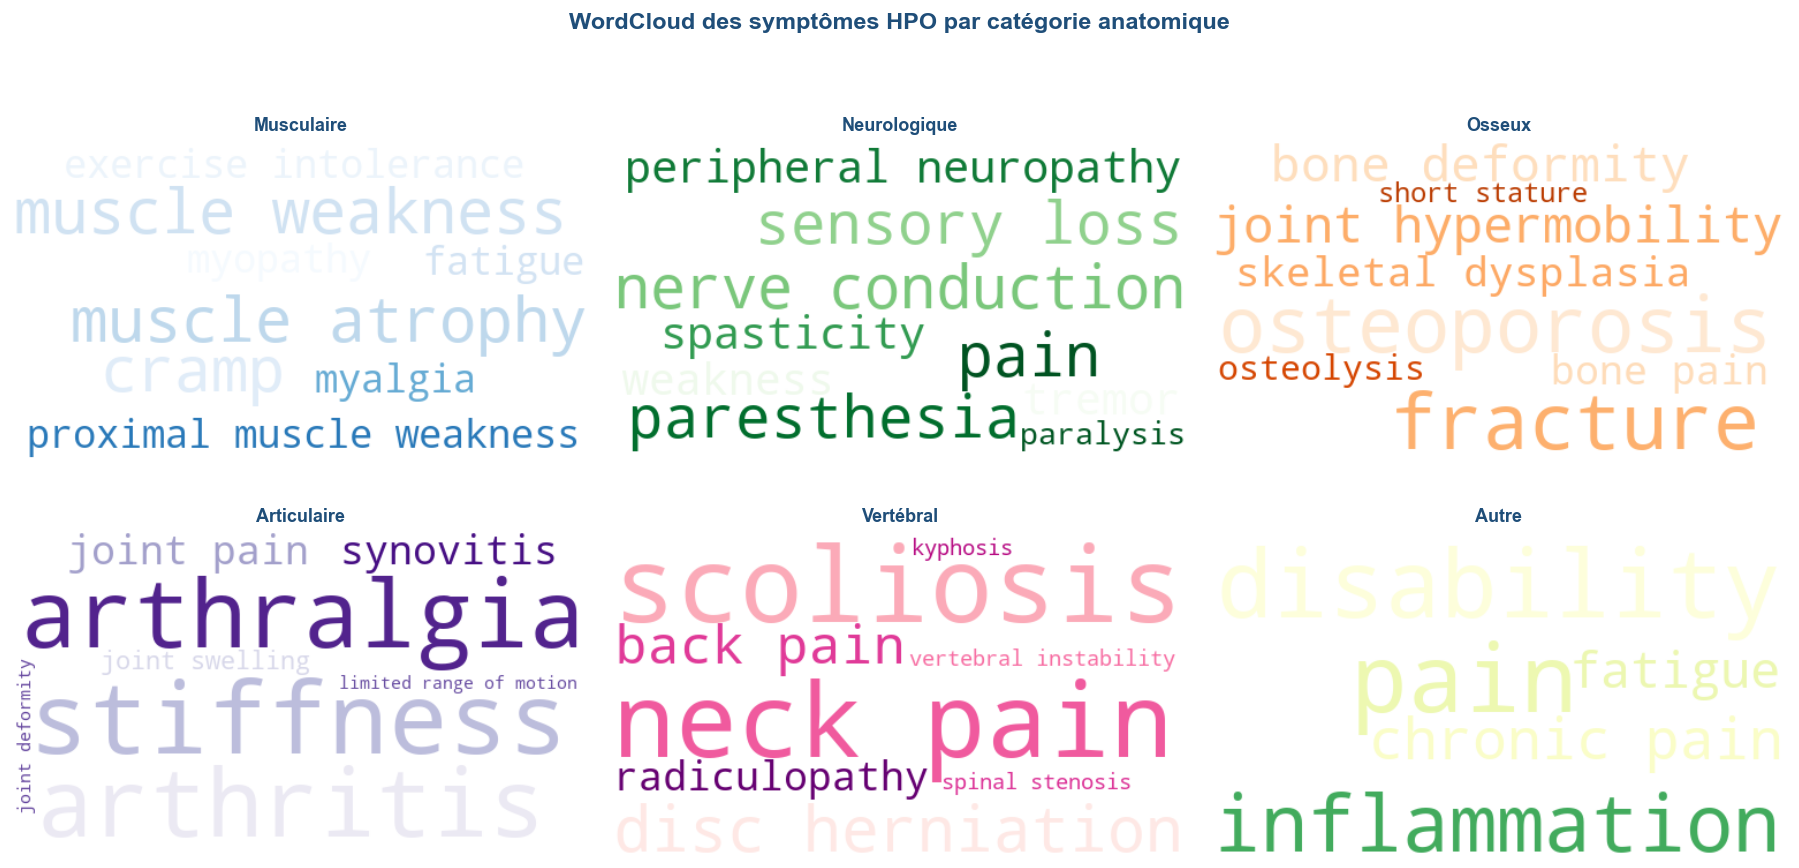

In [16]:
# WordCloud des symptômes HPO les plus fréquents — global et par catégorie anatomique
# Chaque nuage de mots est généré à partir de la fréquence des termes HPO nettoyés

def build_wordcloud(terms_series, title, ax, bg='white', colormap='Blues'):
    """Construit et affiche un WordCloud à partir d'une Series de listes de termes."""
    all_terms = []
    for item in terms_series:
        if isinstance(item, list):
            all_terms.extend(item)
        elif isinstance(item, str):
            all_terms.extend(item.split())
    freq = Counter(all_terms)
    if not freq:
        ax.axis('off')
        return
    wc = WordCloud(
        width=500, height=280, background_color=bg,
        colormap=colormap, max_words=60,
        prefer_horizontal=0.8, min_font_size=8,
        collocations=False
    ).generate_from_frequencies(freq)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=10, fontweight='bold', color=ELARAMED_BLUE, pad=6)

# WordCloud global
fig, ax = plt.subplots(figsize=(12, 4))
build_wordcloud(df['hpo_clean'], 'Symptômes HPO les plus fréquents — Dataset complet', ax, colormap='YlOrRd')
plt.tight_layout()
plt.savefig('fig_wordcloud_global.png', bbox_inches='tight')
plt.show()

# WordCloud par catégorie
cats_wc    = df['anatomical_category'].value_counts().head(6).index
cmaps_list = ['Blues','Greens','Oranges','Purples','RdPu','YlGn']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for idx, (cat, cmap_name) in enumerate(zip(cats_wc, cmaps_list)):
    subset = df[df['anatomical_category'] == cat]['hpo_clean']
    build_wordcloud(subset, f'{cat.capitalize()}', axes[idx], colormap=cmap_name)
plt.suptitle('WordCloud des symptômes HPO par catégorie anatomique',
             fontsize=13, fontweight='bold', color=ELARAMED_BLUE, y=1.01)
plt.tight_layout()
plt.savefig('fig_wordcloud_by_category.png', bbox_inches='tight')
plt.show()

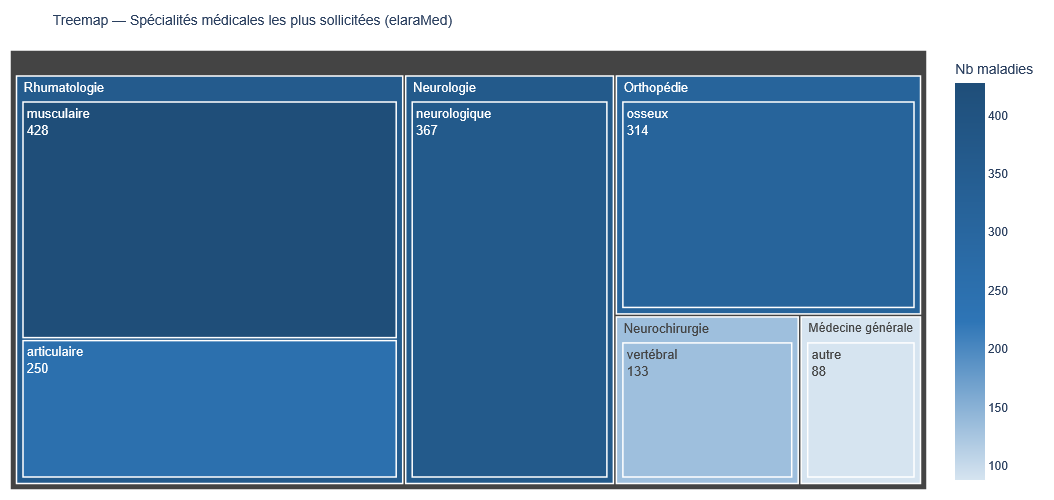

In [17]:
# Treemap interactif (Plotly) — spécialités médicales les plus sollicitées
# La taille de chaque case est proportionnelle au nombre de maladies orientées vers cette spécialité
if 'medical_specialty' in df.columns:
    spec_cat = df.groupby(['medical_specialty', 'anatomical_category']).size().reset_index(name='count')
    spec_cat['total'] = spec_cat.groupby('medical_specialty')['count'].transform('sum')

    fig = px.treemap(
        spec_cat,
        path=['medical_specialty', 'anatomical_category'],
        values='count',
        color='count',
        color_continuous_scale=[
            [0.0,  '#D6E4F0'],
            [0.4,  '#2E75B6'],
            [1.0,  '#1F4E79']
        ],
        title='Treemap — Spécialités médicales les plus sollicitées (elaraMed)',
        hover_data={'count': True}
    )
    fig.update_traces(
        textinfo='label+value',
        textfont_size=13,
        marker_line_width=1.5,
        marker_line_color='white'
    )
    fig.update_layout(
        font_family='Arial',
        title_font_size=14,
        height=500,
        margin=dict(t=50, l=10, r=10, b=10),
        coloraxis_colorbar_title='Nb maladies'
    )
    fig.show()

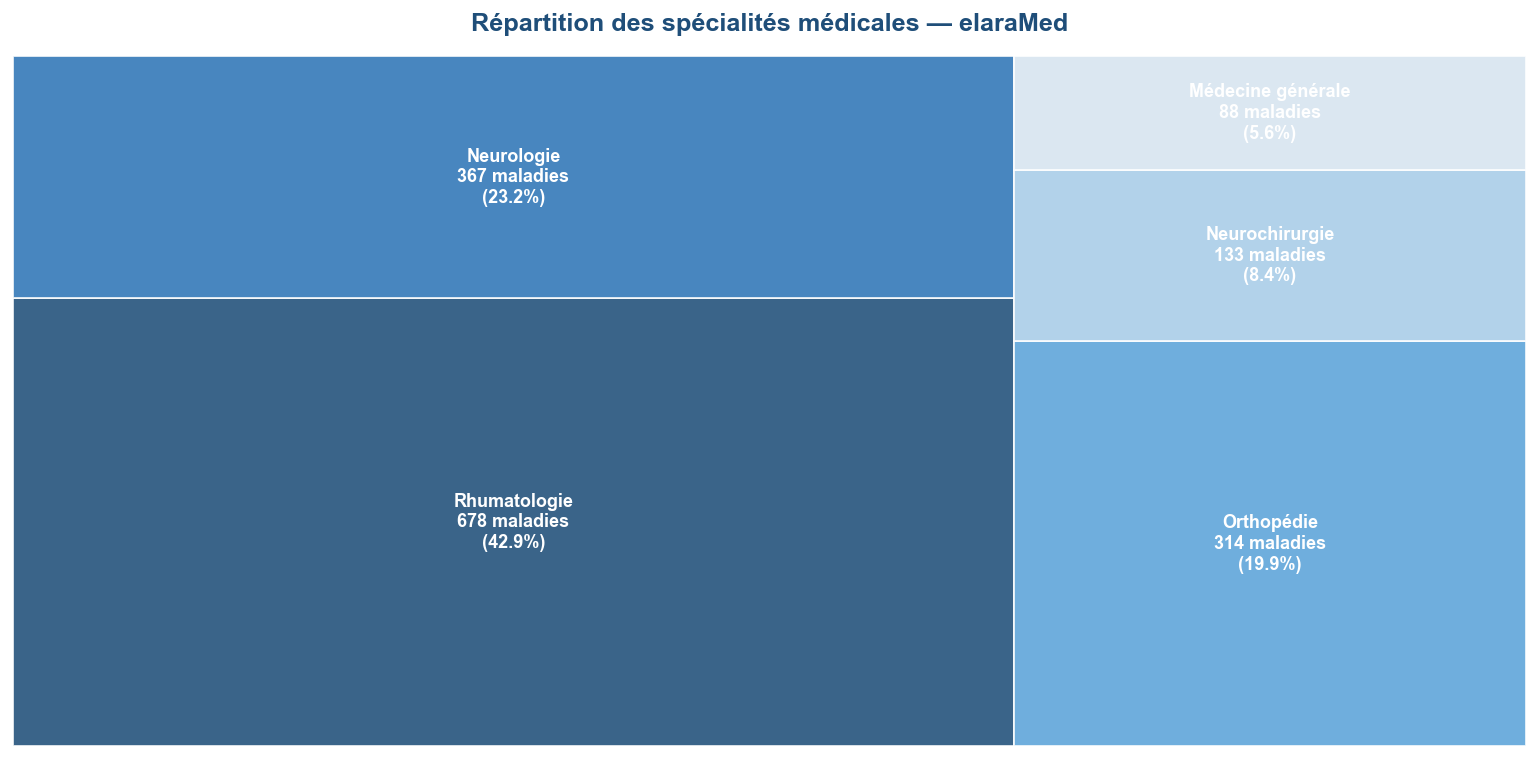

In [18]:
# Treemap statique (matplotlib + squarify) — version exportable en PNG pour le rapport
if 'medical_specialty' in df.columns:
    spec_counts = df['medical_specialty'].value_counts()
    sizes  = spec_counts.values
    labels = [f"{s}\n{v} maladies\n({v/len(df)*100:.1f}%)" for s, v in zip(spec_counts.index, sizes)]
    colors_tm = PALETTE_CAT[:len(sizes)]

    fig, ax = plt.subplots(figsize=(12, 6))
    squarify.plot(
        sizes=sizes, label=labels, color=colors_tm,
        alpha=0.88, text_kwargs={'fontsize': 10, 'fontweight': 'bold', 'color': 'white'},
        ax=ax
    )
    ax.set_title('Répartition des spécialités médicales — elaraMed',
                 fontsize=14, fontweight='bold', color=ELARAMED_BLUE)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('fig_treemap_specialites.png', bbox_inches='tight')
    plt.show()

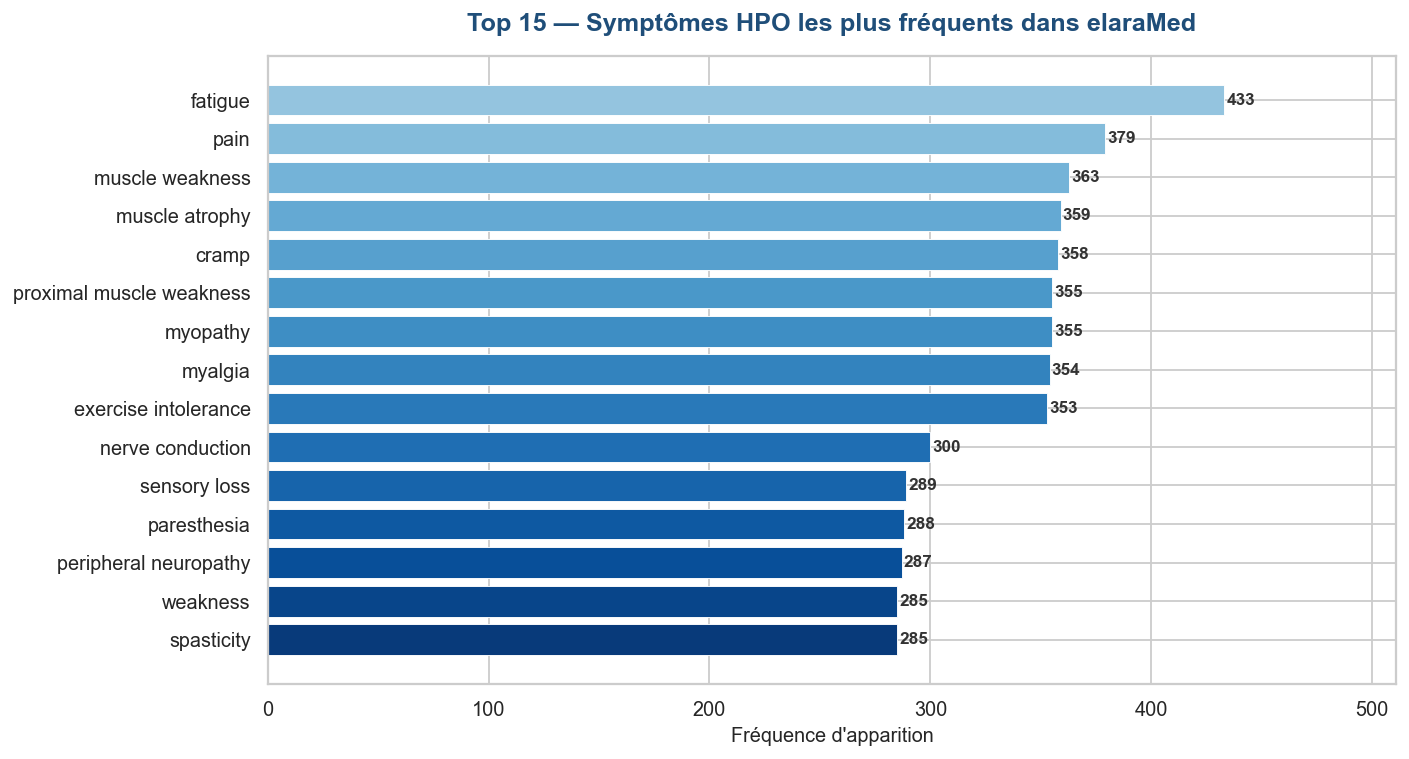

In [19]:
# Top 15 symptômes HPO les plus fréquents — barplot horizontal enrichi
# Permet d'identifier les signaux cliniques dominants pour la recommandation elaraMed
all_symptoms = []
for terms in df['hpo_clean']:
    if isinstance(terms, list):
        all_symptoms.extend(terms)
    elif isinstance(terms, str):
        all_symptoms.extend(terms.split())

top_symptoms = pd.Series(Counter(all_symptoms)).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 6))
gradient_colors = [plt.cm.Blues(0.4 + 0.6 * (i / len(top_symptoms))) for i in range(len(top_symptoms)-1, -1, -1)]
bars = ax.barh(
    top_symptoms.index[::-1], top_symptoms.values[::-1],
    color=gradient_colors, edgecolor='white', linewidth=0.5
)
for bar, val in zip(bars, top_symptoms.values[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9.5, fontweight='bold', color='#333')

ax.set_title('Top 15 — Symptômes HPO les plus fréquents dans elaraMed',
             fontsize=14, fontweight='bold', color=ELARAMED_BLUE)
ax.set_xlabel('Fréquence d\'apparition', fontsize=11)
ax.set_xlim(0, top_symptoms.max() * 1.18)
plt.tight_layout()
plt.savefig('fig_top_symptoms.png', bbox_inches='tight')
plt.show()

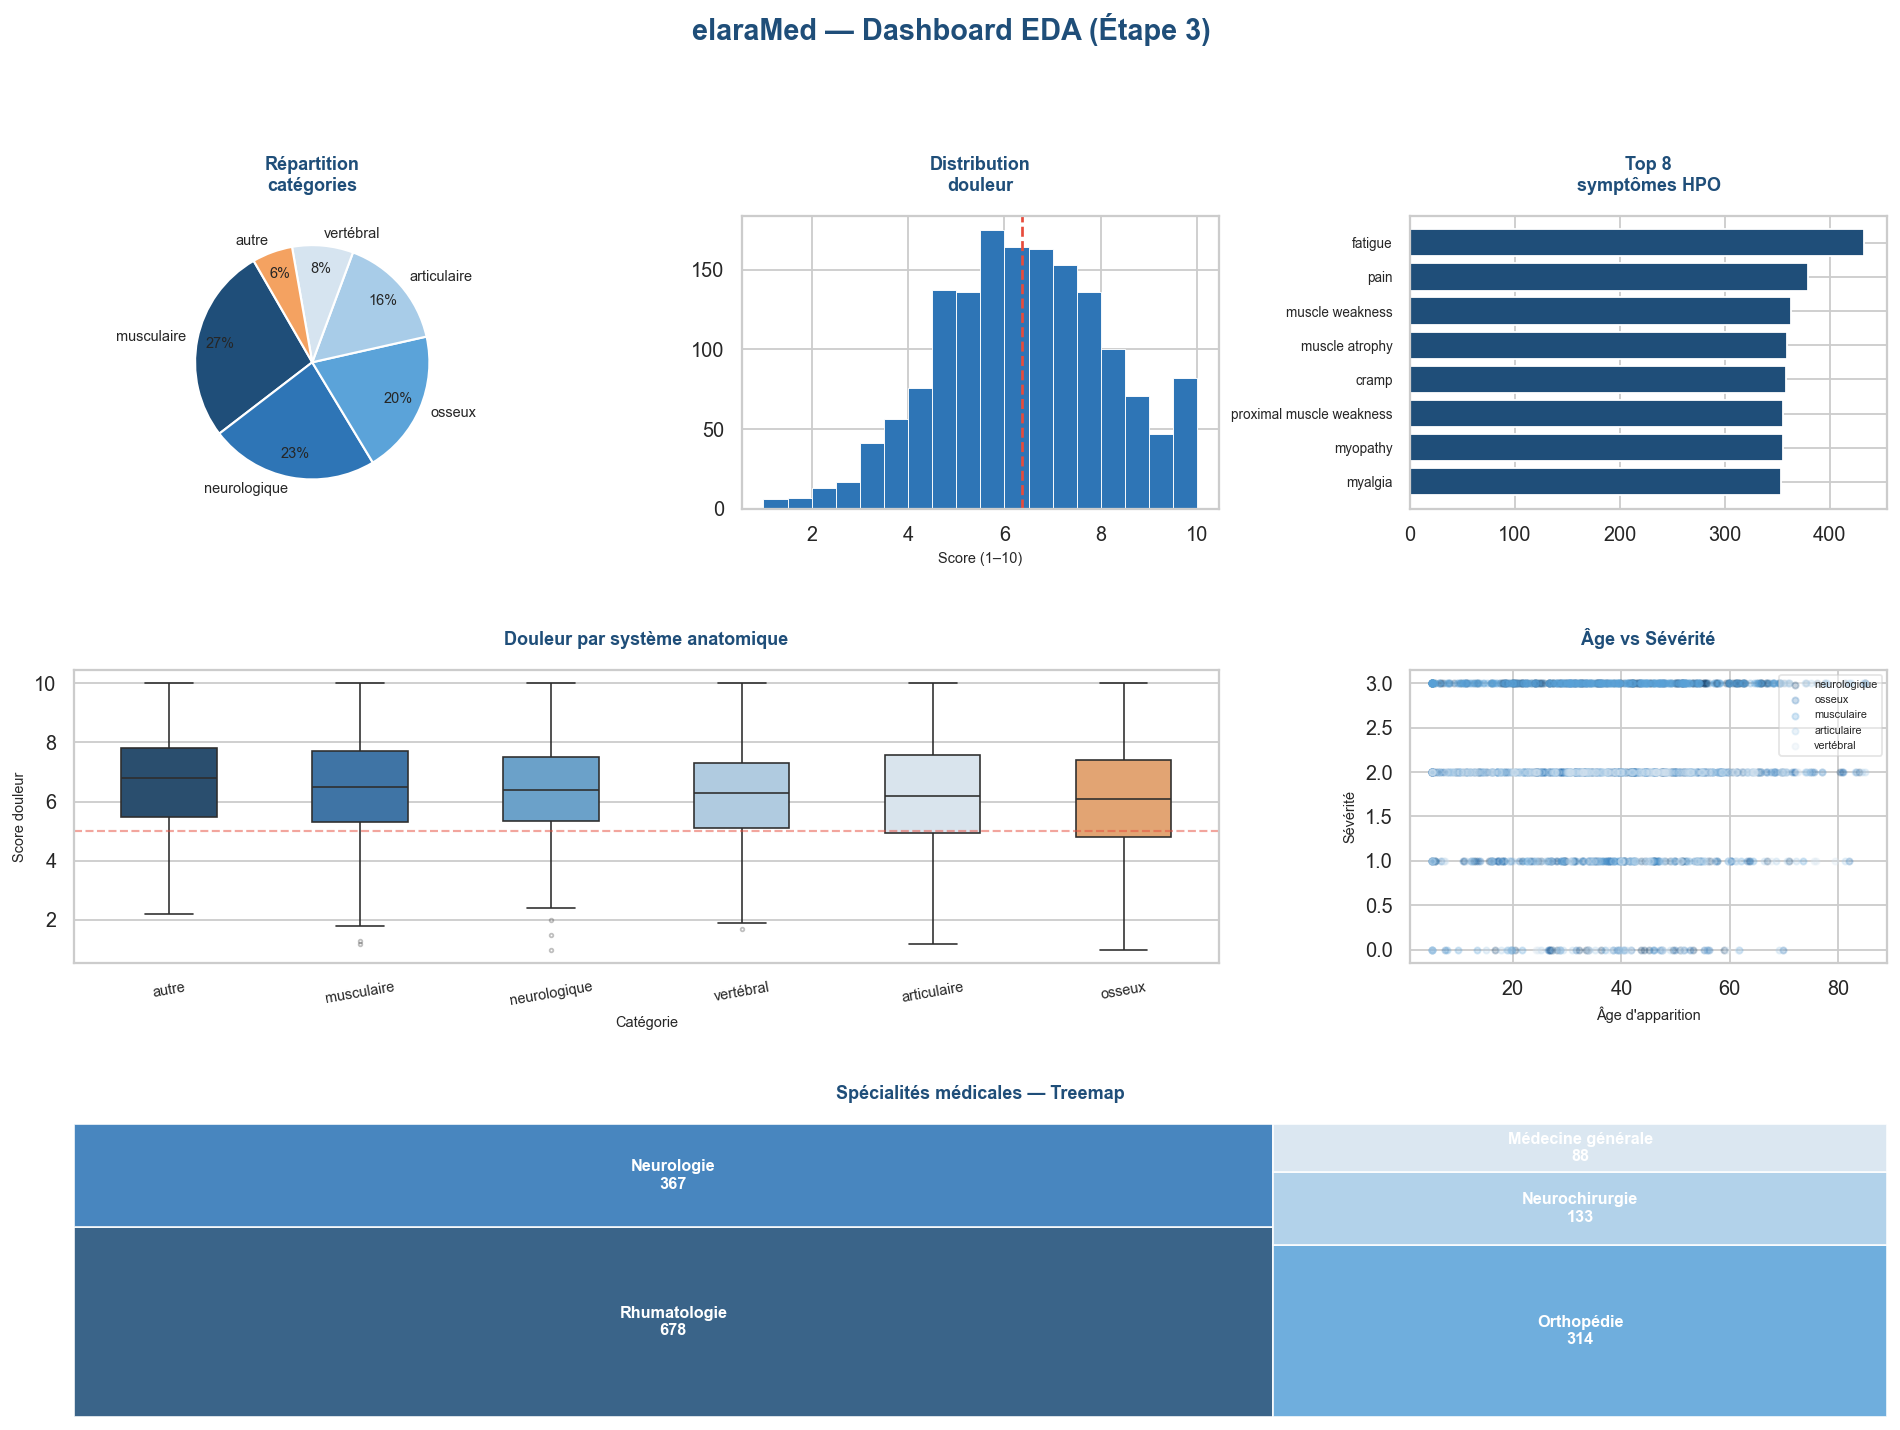

✅ Dashboard exporté → fig_dashboard_EDA.png


In [20]:
# Dashboard récapitulatif — 6 visualisations clés sur une seule figure exportable
# Synthèse visuelle complète de l'EDA pour insertion dans le rapport de l'étape 3
fig = plt.figure(figsize=(18, 12))
gs  = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.40)

# -- [0,0] Pie chart catégories
ax1 = fig.add_subplot(gs[0, 0])
cat_c = df['anatomical_category'].value_counts()
ax1.pie(cat_c.values, labels=cat_c.index, colors=PALETTE_CAT[:len(cat_c)],
        autopct='%1.0f%%', startangle=120, pctdistance=0.80,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
        textprops={'fontsize': 8})
ax1.set_title('Répartition\ncatégories', fontsize=10, fontweight='bold', color=ELARAMED_BLUE)

# -- [0,1] Histogramme douleur
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df['pain_intensity'].dropna(), bins=18, color=ELARAMED_MED, edgecolor='white', linewidth=0.5)
ax2.axvline(df['pain_intensity'].mean(), color=ACCENT, linestyle='--', linewidth=1.5)
ax2.set_title('Distribution\ndouleur', fontsize=10, fontweight='bold', color=ELARAMED_BLUE)
ax2.set_xlabel('Score (1–10)', fontsize=8)

# -- [0,2] Top 8 symptômes
ax3 = fig.add_subplot(gs[0, 2])
top8 = top_symptoms.head(8)
ax3.barh(top8.index[::-1], top8.values[::-1], color=ELARAMED_BLUE, edgecolor='white')
ax3.set_title('Top 8\nsymptômes HPO', fontsize=10, fontweight='bold', color=ELARAMED_BLUE)
ax3.tick_params(axis='y', labelsize=7.5)

# -- [1,0:2] Boxplot douleur par catégorie
ax4 = fig.add_subplot(gs[1, :2])
sns.boxplot(data=df, x='anatomical_category', y='pain_intensity',
            order=order, palette=PALETTE_CAT[:len(order)],
            width=0.5, ax=ax4, linewidth=0.9,
            flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3})
ax4.axhline(5, linestyle='--', color=ACCENT, alpha=0.5, linewidth=1.2)
ax4.set_title('Douleur par système anatomique', fontsize=10, fontweight='bold', color=ELARAMED_BLUE)
ax4.set_xlabel('Catégorie', fontsize=8)
ax4.set_ylabel('Score douleur', fontsize=8)
ax4.tick_params(axis='x', rotation=10, labelsize=8)

# -- [1,2] Scatter âge vs sévérité
ax5 = fig.add_subplot(gs[1, 2])
for cat, color in zip(df['anatomical_category'].unique()[:5], PALETTE_CAT):
    sub = df[df['anatomical_category'] == cat]
    ax5.scatter(sub['age_onset'], sub['severity_score'], alpha=0.25, s=12, color=color, label=cat)
ax5.set_title('Âge vs Sévérité', fontsize=10, fontweight='bold', color=ELARAMED_BLUE)
ax5.set_xlabel('Âge d\'apparition', fontsize=8)
ax5.set_ylabel('Sévérité', fontsize=8)
ax5.legend(fontsize=6, loc='upper right', framealpha=0.5)

# -- [2,:] Treemap spécialités
ax6 = fig.add_subplot(gs[2, :])
if 'medical_specialty' in df.columns:
    spec_c = df['medical_specialty'].value_counts()
    labels_tm = [f"{s}\n{v}" for s, v in zip(spec_c.index, spec_c.values)]
    squarify.plot(sizes=spec_c.values, label=labels_tm,
                  color=PALETTE_CAT[:len(spec_c)], alpha=0.88, ax=ax6,
                  text_kwargs={'fontsize': 9, 'fontweight': 'bold', 'color': 'white'})
ax6.set_title('Spécialités médicales — Treemap', fontsize=10, fontweight='bold', color=ELARAMED_BLUE)
ax6.axis('off')

fig.suptitle('elaraMed — Dashboard EDA (Étape 3)', fontsize=16, fontweight='bold',
             color=ELARAMED_BLUE, y=1.01)
plt.savefig('fig_dashboard_EDA.png', bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Dashboard exporté → fig_dashboard_EDA.png')

#### Génère automatiquement les principaux indicateurs issus de l’analyse exploratoire.
#### Identifie les tendances majeures du dataset (catégorie dominante, douleur, symptômes, sévérité).
#### Affiche une synthèse des résultats obtenus.
#### Prépare les données pour l’étape de modélisation machine learning.


In [21]:
# Synthèse textuelle automatique des principaux insights dégagés lors de l'EDA
print('=' * 62)
print('          SYNTHÈSE EDA — elaraMed Étape 3')
print('=' * 62)

top_cat    = df['anatomical_category'].value_counts().idxmax()
top_cat_pct= df['anatomical_category'].value_counts(normalize=True).max() * 100
avg_pain   = df['pain_intensity'].mean()
avg_symp   = df['num_symptoms_clean'].mean()
top_symp   = top_symptoms.index[0]

if 'medical_specialty' in df.columns:
    top_spec = df['medical_specialty'].value_counts().idxmax()
else:
    top_spec = 'N/A'

insights = [
    f"📌 Catégorie dominante : '{top_cat}' ({top_cat_pct:.1f}% des maladies)",
    f"📌 Intensité de douleur moyenne : {avg_pain:.2f} / 10",
    f"📌 Nombre moyen de symptômes HPO par maladie : {avg_symp:.1f}",
    f"📌 Symptôme HPO le plus fréquent : '{top_symp}'",
    f"📌 Spécialité médicale la plus sollicitée : {top_spec}",
    f"📌 Maladies avec sévérité > 2 : {(df['severity_score'] > 2).sum()} ({(df['severity_score'] > 2).mean()*100:.1f}%)",
    f"📌 Taille du dataset final : {len(df)} maladies × {df.shape[1]} features",
]

for ins in insights:
    print(ins)

print()

          SYNTHÈSE EDA — elaraMed Étape 3
📌 Catégorie dominante : 'musculaire' (27.1% des maladies)
📌 Intensité de douleur moyenne : 6.36 / 10
📌 Nombre moyen de symptômes HPO par maladie : 6.6
📌 Symptôme HPO le plus fréquent : 'fatigue'
📌 Spécialité médicale la plus sollicitée : Rhumatologie
📌 Maladies avec sévérité > 2 : 589 (37.3%)
📌 Taille du dataset final : 1580 maladies × 11 features

